# Overview:


*   Diabetes is a chronic condition where your body cannot properly process glucose (sugar) from food, leading to persistently high blood sugar levels. This happened because the pancreas doesn't produce enough insulin, or the body cannot use it effectively

### Main Types of Diabetes


*   Type 1 Diabetes: An autoimmune disease where the body's immune system attacks and destroys insulin-producing cells in the pancreas. People with Type 1 produce little to no insulin and require daily insulin administration.
*   Type 2 Diabetes: The most common form. The body still produces insulin, but cells become resistant and cannot use it properly. It is often managed with lifestyle changes, diet, and sometimes medication or insulin.
* Gestational Diabetes: Develops in some women during pregnancy. While it usually resolves after childbirth, it increases the risk of developing Type 2 diabetes later in life.
* Prediabetes: Blood sugar levels are higher than normal but not yet high enough to be officially diagnosed as Type 2 diabetes

### Type 2 Diabetes vs Type 1 Diabetes and Gestational Diabetes
* Type 1 Diabetes is less common than Type 2 Diabetes because Type 1 Diabetes caused by Autoimmune disease destroys insulin producing beta cells in the pancreas and this autoimmune diseases are relatively rare (only about 5-10% of people with diabetes have Type 1).

* Gestational Diabetes is also less common than Type 2 Diabetes because it only occurs during pregnancy, and not every pregnant woman develops enough insulin resistance to cause diabetes.

* Unlike Type 1 Diabetes and Gestational Diabetes, Type 2 Diabetes is very common because many people develop insulin resistance due to aging, obesity, physical inactivity, poor diet, and genetics. Which led to about 90-95% of diabetes cases are Type 2.


### In this project, we will use Machine Learning model to predict whether a person has Type 2 Diabetes, No Diabetes, or Pre-diabetes. The dataset does included the Type 1 Diabetes and Gestational Diabetes but as we discussed above, those two type of diabetes are very rare (because the causes are not common in the population abd the features are not enough to support that).

# The Dataset
### The dataset contains 100,000 patient records across 34 columns, combining demographic, lifestyle, clinical, and laboratory information for each person. Our prediction target is diabetes_stage, which places each patient on the metabolic continuum from healthy to diabetic.
### The raw target distribution is imbalanced and spans five categories: Type 2 (59.8%), Pre-Diabetes (31.8%), No Diabetes (8.0%), Gestational (0.28%), and Type 1 (0.12%). As discussed above, Type 1 and Gestational diabetes together make up less than half a percent of the data and arise from causes this dataset does not capture, so we will focus the model on the three-way distinction between No Diabetes, Pre-Diabetes, and Type 2.
### The columns fall into a few natural groups:


*   Demographic and socioeconomic: `age`, `gender`, `ethnicity`, `education_level`, `income_level`, `employment_status`
*   Lifestyle: `smoking_status`, `alcohol_consumption_per_week`, `physical_activity_minutes_per_week`, `diet_score`, `sleep_hours_per_day`, `screen_time_hours_per_day`
* Clinical history (binary flags): `family_history_diabetes`, `hypertension_history`, `cardiovascular_history`
* Body measures and vitals: `bmi`, `waist_to_hip_ratio`, `systolic_bp`, `diastolic_bp`, `heart_rate`
* Lipid panel: `cholesterol_total`, `hdl_cholesterol`, `ldl_cholesterol`, `triglycerides`
* Glucose and metabolic labs: `glucose_fasting`, `glucose_postprandial`, `insulin_level`, `hba1c`
* Derived and target-adjacent: `diabetes_risk_score`, `diagnosed_diabetes`
* Bookkeeping (not predictive): `patient_tracking_id`, `data_entry_notes`, `experimental_peptide_level`





### Two things are worth flagging before we begin. First, several columns carry missing values (`patient_tracking_id` at 95%, `experimental_peptide_level` at 50%, `data_entry_notes` at 10%, and `age` and `bmi` at 5% each), which the profiling step below will quantify. Second, two columns are close relatives of the target: `diagnosed_diabetes` is essentially the diagnosis itself, and hba1c are lab-derived measures that may carry the answer rather than predict it. We will return to this leakage question in detail once we reach the modeling stage.

### Load all the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Iterable
import math
from __future__ import annotations

### Define the function to inspect the dataset


*   Check data-type (e.g. Interger value such as age cannot be different kind such as text)
*   Checking for missing values, duplicates, and data shape



In [2]:
# Tokens that commonly encode "missing" as text. Matched case-insensitively.
DEFAULT_NA_TOKENS: set[str] = {
    "", "?", "-", "--", "na", "n/a", "nan", "none", "null", "unknown", "missing",
}


def profile_dataset(
    df: pd.DataFrame,
    na_tokens: Iterable[str] = DEFAULT_NA_TOKENS,
    categorical_max_card: int = 25,
    verbose: bool = True,
) -> dict:
    """
    Step 1 - Initial profiling.

    Inspect a raw dataframe *without changing it* and return a structured
    profile describing its health. Profiling first is a non-negotiable habit:
    it prevents blind imputation and surfaces problems (wrong dtypes, hidden
    missing markers, low-information columns) that summary stats alone hide.

    Parameters
    ----------
    df : pd.DataFrame
        The raw dataframe to inspect. It is never mutated.
    na_tokens : iterable of str
        Strings that should be treated as "missing" when hunting for values
        hidden inside text columns (e.g. "?", "N/A", "unknown").
    categorical_max_card : int
        Columns with at most this many unique values get a full value-count
        breakdown in the report.
    verbose : bool
        If True, print a human-readable profiling report.

    Returns
    -------
    dict
        {
          'n_rows', 'n_cols', 'duplicate_rows',
          'columns': {col: {dtype, n_missing, pct_missing, n_unique, kind, ...}},
          'text_typed_numeric': [cols read as text but actually numeric],
          'high_missing': [cols missing >= 50% of rows],
          'constant': [zero-variance / single-value cols],
        }
    """
    na_set = {str(t).strip().lower() for t in na_tokens}
    n_rows, n_cols = df.shape

    columns: dict[str, dict] = {}
    text_typed_numeric: list[str] = []
    high_missing: list[str] = []
    constant: list[str] = []

    for col in df.columns:
        column = df[col]
        n_missing = int(column.isna().sum())
        pct_missing = round(column.isna().mean() * 100, 2)
        n_unique = int(column.nunique(dropna=True))
        is_numeric = pd.api.types.is_numeric_dtype(column)

        info: dict = {
            "dtype": str(column.dtype),
            "n_missing": n_missing,
            "pct_missing": pct_missing,
            "n_unique": n_unique,
        }

        # --- classify the column kind ---
        if is_numeric:
            unique_vals = set(column.dropna().unique().tolist())
            if unique_vals <= {0, 1}:
                info["kind"] = "binary"
            else:
                info["kind"] = "numeric"
            desc = column.describe()
            info["min"] = round(float(column.min()), 3)
            info["p1"] = round(float(column.quantile(0.01)), 3)
            info["median"] = round(float(column.median()), 3)
            info["p99"] = round(float(column.quantile(0.99)), 3)
            info["max"] = round(float(column.max()), 3)
        else:
            info["kind"] = "categorical"
            # Hunt for missing markers hiding inside a text column, and decide
            # whether the "real" content is actually numeric.
            as_str = column.dropna().astype(str).str.strip()
            found_tokens = sorted({v for v in as_str.unique() if v.lower() in na_set})
            info["hidden_na_tokens"] = found_tokens
            info["hidden_na_count"] = int(as_str.str.lower().isin(na_set).sum())

            real = as_str[~as_str.str.lower().isin(na_set)]
            coerced = pd.to_numeric(real, errors="coerce")
            if len(real) > 0 and coerced.notna().all():
                info["kind"] = "numeric (text-typed)"
                text_typed_numeric.append(col)
            elif n_unique <= categorical_max_card:
                info["value_counts"] = column.value_counts(dropna=False).to_dict()

        # --- flag low-information / high-missing columns ---
        # effective unique count treats hidden NA tokens as a single "missing"
        if n_unique <= 1:
            constant.append(col)
        if pct_missing >= 50:
            high_missing.append(col)

        columns[col] = info

    profile = {
        "n_rows": n_rows,
        "n_cols": n_cols,
        "duplicate_rows": int(df.duplicated().sum()),
        "columns": columns,
        "text_typed_numeric": text_typed_numeric,
        "high_missing": high_missing,
        "constant": constant,
    }

    if verbose:
        _print_profile(profile)

    return profile


def _print_profile(p: dict) -> None:
    """Render a profile dict as a readable console report."""
    line = "=" * 78
    print(line)
    print("STEP 1 - INITIAL PROFILING")
    print(line)
    print(f"Rows: {p['n_rows']:,}    Columns: {p['n_cols']}    "
          f"Duplicate rows: {p['duplicate_rows']:,}")

    # Per-column table
    print("\nPer-column overview")
    print("-" * 78)
    print(f"{'column':<38}{'kind':<22}{'%miss':>7}{'unique':>10}")
    print("-" * 78)
    for col, info in p["columns"].items():
        print(f"{col:<38}{info['kind']:<22}{info['pct_missing']:>6.1f}%{info['n_unique']:>10,}")

    # Warnings block
    def block(title, items, extra=None):
        if not items:
            return
        print(f"\n{title}")
        print("-" * 78)
        for c in items:
            note = ""
            if extra:
                note = extra(c)
            print(f"  - {c}{note}")

    block("Columns read as TEXT but actually NUMERIC (hidden markers inside)",
          p["text_typed_numeric"],
          lambda c: f"   tokens={p['columns'][c].get('hidden_na_tokens')} "
                    f"(x{p['columns'][c].get('hidden_na_count')})")
    block("Columns with >= 50% missing (drop / investigate)",
          p["high_missing"],
          lambda c: f"   ({p['columns'][c]['pct_missing']:.0f}% missing)")
    block("Constant / single-value columns (zero information)", p["constant"])

    # Missing-value summary
    miss = {c: i["pct_missing"] for c, i in p["columns"].items() if i["pct_missing"] > 0}
    if miss:
        print("\nColumns with missing values")
        print("-" * 78)
        for c, v in sorted(miss.items(), key=lambda x: -x[1]):
            print(f"  - {c:<38}{v:>6.1f}%")
    print(line)



In [3]:
path = 'diabetes.csv'
raw = pd.read_csv(path)
profile_dataset(raw)

STEP 1 - INITIAL PROFILING
Rows: 100,000    Columns: 34    Duplicate rows: 0

Per-column overview
------------------------------------------------------------------------------
column                                kind                    %miss    unique
------------------------------------------------------------------------------
age                                   numeric                  5.0%        73
gender                                categorical              0.0%         3
ethnicity                             categorical              0.0%         5
education_level                       categorical              0.0%         4
income_level                          categorical              0.0%         5
employment_status                     categorical              0.0%         4
smoking_status                        categorical              0.0%         3
alcohol_consumption_per_week          numeric                  0.0%        11
physical_activity_minutes_per_week    nume

{'n_rows': 100000,
 'n_cols': 34,
 'duplicate_rows': 0,
 'columns': {'age': {'dtype': 'float64',
   'n_missing': 5000,
   'pct_missing': np.float64(5.0),
   'n_unique': 73,
   'kind': 'numeric',
   'min': 18.0,
   'p1': 18.0,
   'median': 50.0,
   'p99': 87.0,
   'max': 90.0},
  'gender': {'dtype': 'object',
   'n_missing': 0,
   'pct_missing': np.float64(0.0),
   'n_unique': 3,
   'kind': 'categorical',
   'hidden_na_tokens': [],
   'hidden_na_count': 0,
   'value_counts': {'Female': 50216, 'Male': 47771, 'Other': 2013}},
  'ethnicity': {'dtype': 'object',
   'n_missing': 0,
   'pct_missing': np.float64(0.0),
   'n_unique': 5,
   'kind': 'categorical',
   'hidden_na_tokens': [],
   'hidden_na_count': 0,
   'value_counts': {'White': 44997,
    'Hispanic': 20103,
    'Black': 17986,
    'Asian': 11865,
    'Other': 5049}},
  'education_level': {'dtype': 'object',
   'n_missing': 0,
   'pct_missing': np.float64(0.0),
   'n_unique': 4,
   'kind': 'categorical',
   'hidden_na_tokens': [],


*   As the result above, we see there are few columns having missing values (age, bmi, patient_tracking_id, data_entry_notes, experimental_peptide_level)
*   Also, we see data type if conflicted. The data type for cholesterol_total and glucose-fasting should be numeric but it is classified as text in the dataset

### From the dataset overview above, three columns — `patient_tracking_id`, `data_entry_notes`, and `experimental_peptide_level` — have a significant number of missing values. `data_entry_notes` has a uniqueness of 1, so keeping or dropping it won't affect model behavior. The other two columns have so much missing data that dropping the rows would cause substantial data loss (`patient_tracking_id` alone is 95% missing), so it's better to drop these columns entirely.

In [4]:
DROP_COLUMNS: list[str] = [
    "patient_tracking_id",
    "data_entry_notes",
    "experimental_peptide_level",
]


def drop_uninformative_columns(
    df: pd.DataFrame,
    columns: Iterable[str] = DROP_COLUMNS,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Step 2 - remove non-informative columns.

    Returns a NEW dataframe with `columns` removed (the input is not mutated).
    Any requested column that is not present is silently skipped, so the
    function is safe to re-run and reusable on other datasets.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe to clean.
    columns : iterable of str
        Column names to drop. Defaults to the three junk columns above.
    verbose : bool
        If True, print what was dropped.
    """
    to_drop = [c for c in columns if c in df.columns]
    out = df.drop(columns=to_drop)
    if verbose:
        print(f"STEP 2 - dropped {len(to_drop)} column(s): {to_drop}")
        print(f"         shape {df.shape} -> {out.shape}")
    return out

In [5]:
df = drop_uninformative_columns(raw)
df.head()

STEP 2 - dropped 3 column(s): ['patient_tracking_id', 'data_entry_notes', 'experimental_peptide_level']
         shape (100000, 34) -> (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


### We need to define a realistic range for each measurement, because if a value falls outside what's physically possible, the result becomes meaningless.

In [6]:
# ---------------------------------------------------------------------------
# STEPS 3 + 4 - Detect & fix weird values (hidden markers + impossible values)
# ---------------------------------------------------------------------------

# Physiologically plausible ranges for the medical columns. A value outside its
# range is treated as a data-entry error and set to NaN (imputed later), NOT as
# a rare-but-real reading. Bounds are deliberately GENEROUS so genuine variation
# is preserved -- only impossible values are caught (e.g. systolic 300 mmHg,
# 5,000 exercise-minutes/week). Override this dict to reuse on other datasets.
PLAUSIBLE_BOUNDS: dict[str, tuple[float, float]] = {
    "age": (0, 100),
    "bmi": (12, 100),
    "waist_to_hip_ratio": (0.5, 1.2),
    "systolic_bp": (90, 250),
    "diastolic_bp": (50, 150),
    "heart_rate": (30, 180),
    "sleep_hours_per_day": (0, 24),
    "screen_time_hours_per_day": (0, 24),
    "physical_activity_minutes_per_week": (0, 2000),
    "diet_score": (0, 10),
    "cholesterol_total": (50, 500),
    "hdl_cholesterol": (10, 150),
    "ldl_cholesterol": (10, 400),
    "triglycerides": (20, 1000),
    "glucose_fasting": (40, 500),
    "glucose_postprandial": (40, 600),
    "insulin_level": (0, 100),
    "hba1c": (3, 20),
    "diabetes_risk_score": (0, 100),
}


def detect_and_fix_weird_values(
    df: pd.DataFrame,
    na_tokens: Iterable[str] = DEFAULT_NA_TOKENS,
    bounds: dict[str, tuple[float, float]] = PLAUSIBLE_BOUNDS,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Steps 3 & 4 - find weird values and convert them to NaN.

    Two kinds of weirdness, handled separately:

      (3) Hidden text markers ("?", "N/A", "unknown", ...) inside otherwise
          numeric columns. Token cells become NaN; a column whose real content
          is fully numeric is then converted to a numeric dtype. Genuine text
          categoricals are left as text (only their token cells are nulled).

      (4) Impossible values, detected against per-column plausibility `bounds`.
          Anything outside [low, high] is set to NaN.

    Nothing is imputed here -- weird values are simply marked missing so the
    imputation step (next) can fill them consistently. Returns a NEW dataframe.
    """
    out = df.copy()
    na_set = {str(t).strip().lower() for t in na_tokens}
    token_report: dict[str, dict] = {}
    range_report: dict[str, dict] = {}

    # --- Step 3: hidden text markers -> NaN, coerce text-typed numerics ---
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            continue
        s = out[col].astype("string").str.strip()
        tok_mask = s.str.lower().isin(na_set)
        found = sorted({v for v in s[tok_mask].dropna().unique()})
        if tok_mask.any():
            s = s.mask(tok_mask, other=pd.NA)

        coerced = pd.to_numeric(s, errors="coerce")
        n_nonnull = int(s.notna().sum())
        if n_nonnull > 0 and int(coerced.notna().sum()) == n_nonnull:
            out[col] = coerced                       # numeric hiding as text
            if found:
                token_report[col] = {"tokens": found, "count": int(tok_mask.sum()),
                                      "coerced_to_numeric": True}
        else:
            out[col] = s                             # genuine categorical
            if found:
                token_report[col] = {"tokens": found, "count": int(tok_mask.sum()),
                                      "coerced_to_numeric": False}

    # --- Step 4: impossible values (out of plausible range) -> NaN ---
    for col, (lo, hi) in bounds.items():
        if col not in out.columns or not pd.api.types.is_numeric_dtype(out[col]):
            continue
        col_s = out[col]
        bad_mask = (col_s < lo) | (col_s > hi)
        n_bad = int(bad_mask.sum())
        if n_bad:
            examples = sorted(col_s[bad_mask].dropna().unique().tolist())
            range_report[col] = {"bounds": (lo, hi), "count": n_bad,
                                 "examples": examples[:5]}
            out.loc[bad_mask, col] = np.nan

    if verbose:
        _print_weird_report(df, out, token_report, range_report)
    return out


def _print_weird_report(before, after, token_report, range_report) -> None:
    line = "=" * 78
    print(line)
    print("STEPS 3 & 4 - DETECT & FIX WEIRD VALUES")
    print(line)

    print("\n[3] Hidden text markers converted to NaN")
    print("-" * 78)
    if token_report:
        for col, r in token_report.items():
            tag = "-> coerced to numeric" if r["coerced_to_numeric"] else "-> kept as category"
            print(f"  - {col:<34}{str(r['tokens']):<10} x{r['count']:<6} {tag}")
    else:
        print("  (none found)")

    print("\n[4] Impossible values converted to NaN (outside plausible range)")
    print("-" * 78)
    if range_report:
        for col, r in range_report.items():
            print(f"  - {col:<34}allowed {str(r['bounds']):<14} "
                  f"bad x{r['count']:<5} e.g. {r['examples']}")
    else:
        print("  (none found)")

    added = int(after.isna().sum().sum() - before.isna().sum().sum())
    print("-" * 78)
    print(f"Total cells newly marked missing: {added:,}")
    print(line)

### As we can see, there are two columns containing values outside the range we defined: `systolic_bp` = 300 and `physical_activity_minutes_per_week` = 5000. These values are plausible, though — an athlete could realistically log that much activity, and while `systolic_bp` = 300 would put a person at extreme risk, it's not an impossible value.

In [7]:
df = detect_and_fix_weird_values(df)
df

STEPS 3 & 4 - DETECT & FIX WEIRD VALUES

[3] Hidden text markers converted to NaN
------------------------------------------------------------------------------
  - cholesterol_total                 ['?']      x2000   -> coerced to numeric
  - glucose_fasting                   ['?']      x2000   -> coerced to numeric

[4] Impossible values converted to NaN (outside plausible range)
------------------------------------------------------------------------------
  - systolic_bp                       allowed (90, 250)      bad x5     e.g. [300]
  - physical_activity_minutes_per_weekallowed (0, 2000)      bad x5     e.g. [5000]
------------------------------------------------------------------------------
Total cells newly marked missing: 4,010


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215.0,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143.0,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57.0,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49.0,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109.0,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46.0,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136.0,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,NaN,Female,White,Graduate,Middle,Employed,Never,3,76.0,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57.0,Female,Black,No formal,Upper-Middle,Employed,Former,4,121.0,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47.0,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52.0,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


### We want to fill the missing values with the median of each column instead of the mean, because the presence of outliers would skew the mean toward those extreme values. Even after defining a possible range and converting out-of-range values to NaN, legitimate but extreme values (like the athlete's activity minutes) can still remain — so the median gives a less biased fill value in the presence of that skew.
### Checking the skewness of each numeric column confirms this: most continuous features (age, bmi, systolic_bp, cholesterol_total, etc.) have low skew (|skew| < 0.5), meaning mean and median are close and the choice barely matters for them. physical_activity_minutes_per_week is the clear exception, with a skew of 1.39 — this is exactly the athlete-outlier column discussed above, and it's where median makes the biggest difference. insulin_level and diabetes_risk_score show moderate skew as well, so median is the safer choice there too.
### The three highest-skew columns — cardiovascular_history, family_history_diabetes, and hypertension_history — are binary flags rather than continuous measurements, so their high skew simply reflects class imbalance, not outlier distortion. For these, median/mean imputation isn't appropriate: mean would produce a non-valid fractional value, and median would just collapse to the majority class. We'll impute these with the mode (or a separate "missing" category) instead.

In [8]:
columns = []
skewness = []
for col in df.select_dtypes(include='number').columns:
    columns.append(col)
    skewness.append(df[col].skew())

df_skewness = pd.DataFrame({"Column_Name": columns, "Skew_Value": skewness})
df_skewness

,Column_Name,Skew_Value
0,age,0.083813
1,alcohol_consumption_per_week,0.703343
2,physical_activity_minutes_per_week,1.390031
3,diet_score,-0.070251
4,sleep_hours_per_day,-0.012613
5,screen_time_hours_per_day,0.082573
6,family_history_diabetes,1.356029
7,hypertension_history,1.149799
8,cardiovascular_history,3.116499
9,bmi,0.006733


In [9]:
# ---------------------------------------------------------------------------
# STEP 5 - Impute missing values with the column median
# ---------------------------------------------------------------------------

def impute_median(
    df: pd.DataFrame,
    columns: Iterable[str] | None = None,
    add_flags: bool = False,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Step 5 - fill missing values with each column's median.

    Every NaN produced by Steps 3 & 4 (plus any that were already missing) is
    filled with the median of its own column. The median is used instead of the
    mean because it is robust to skew and to residual outliers, so a few unusual
    patients cannot pull the fill value off-centre.

    Parameters
    ----------
    columns : iterable of str, optional
        Which columns to impute. Defaults to every numeric column that has at
        least one missing value.
    add_flags : bool
        If True, also add a reversible `<col>_was_imputed` column (1 = filled,
        0 = original). Off by default to keep the output simple; turn it on for
        a fully auditable dataset.

    Returns a NEW dataframe with no missing values in the imputed columns.
    """
    out = df.copy()
    if columns is None:
        columns = [c for c in out.columns
                   if pd.api.types.is_numeric_dtype(out[c]) and out[c].isna().any()]

    fills: dict[str, tuple[int, float]] = {}
    for col in columns:
        na_mask = out[col].isna()
        if not na_mask.any():
            continue
        if add_flags:
            out[col + "_was_imputed"] = na_mask.astype(int)
        med = round(float(out[col].median()), 2)
        # cast nullable-int columns to float so a decimal median fits cleanly
        if str(out[col].dtype) in ("Int64", "int64"):
            out[col] = out[col].astype(float)
        out[col] = out[col].fillna(med)
        fills[col] = (int(na_mask.sum()), med)

    if verbose:
        line = "=" * 78
        print(line)
        print("STEP 5 - MEDIAN IMPUTATION")
        print(line)
        print(f"{'column':<40}{'filled':>10}{'median':>14}")
        print("-" * 78)
        for col, (n, med) in fills.items():
            print(f"{col:<40}{n:>10,}{med:>14}")
        print("-" * 78)
        print(f"Missing cells remaining in dataset: {int(out.isna().sum().sum()):,}"
              f"    (flags added: {add_flags})")
        print(line)
    return out

### The values for median are make sense because these values are the standard measurement for a person in real life.

In [10]:
df = impute_median(df)
df

STEP 5 - MEDIAN IMPUTATION
column                                      filled        median
------------------------------------------------------------------------------
age                                          5,000          50.0
physical_activity_minutes_per_week               5         100.0
bmi                                          5,000          25.6
systolic_bp                                      5         116.0
cholesterol_total                            2,000         186.0
glucose_fasting                              2,000         111.0
------------------------------------------------------------------------------
Missing cells remaining in dataset: 0    (flags added: False)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215.0,5.7,...,41,160,145,136.0,236,6.36,8.18,29.6,Type 2,1
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143.0,6.7,...,55,50,30,93.0,150,2.00,5.63,23.0,No Diabetes,0
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57.0,6.4,...,66,99,36,118.0,195,5.07,7.51,44.7,Type 2,1
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49.0,3.4,...,50,79,140,139.0,253,5.28,9.03,38.2,Type 2,1
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109.0,7.2,...,52,125,160,137.0,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46.0,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136.0,8.3,...,45,150,116,113.0,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,50.0,Female,White,Graduate,Middle,Employed,Never,3,76.0,8.8,...,55,123,146,96.0,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57.0,Female,Black,No formal,Upper-Middle,Employed,Former,4,121.0,9.9,...,50,111,184,93.0,132,2.57,5.21,27.6,No Diabetes,0
99998,47.0,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52.0,5.9,...,68,91,116,106.0,117,9.81,5.53,26.4,Pre-Diabetes,0


In [11]:
NAVY = "#1f3a5f"
TEAL = "#2a9d8f"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.size": 10,
})


def plot_numeric_histograms(
    df: pd.DataFrame,
    columns: Iterable[str] | None = None,
    bins: int = 40,
    exclude_binary: bool = False,
    ncols: int = 4,
    show_median: bool = True,
    save_path: str | None = None,
    dpi: int = 130,
):
    """
    Draw a histogram for every integer/float column so you can eyeball each
    distribution at a glance.

    Parameters
    ----------
    df : pd.DataFrame
        The (cleaned) dataframe to explore.
    columns : iterable of str, optional
        Restrict to these columns. Defaults to ALL numeric (int/float) columns.
    bins : int
        Number of histogram bins.
    exclude_binary : bool
        If True, skip 0/1 flag columns (their histograms are just two bars).
    ncols : int
        Number of subplot columns in the grid; rows are computed automatically.
    show_median : bool
        Draw a dashed vertical line at each column's median.
    save_path : str, optional
        If given, the figure is written here (e.g. "histograms.png").
    dpi : int
        Resolution for the saved figure.

    Returns
    -------
    (fig, plotted_columns) : the Matplotlib figure and the list of columns drawn.
    """
    # 1) pick the numeric columns
    if columns is None:
        columns = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    else:
        columns = [c for c in columns if c in df.columns
                   and pd.api.types.is_numeric_dtype(df[c])]

    if exclude_binary:
        columns = [c for c in columns
                   if not set(df[c].dropna().unique()) <= {0, 1}]

    if not columns:
        raise ValueError("No numeric columns to plot.")

    # 2) build the grid
    n = len(columns)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.6))
    axes = np.atleast_1d(axes).ravel()

    # 3) one histogram per column
    for ax, col in zip(axes, columns):
        data = df[col].dropna()
        ax.hist(data, bins=bins, color=NAVY, edgecolor="white", linewidth=0.3)
        if show_median and len(data):
            med = data.median()
            ax.axvline(med, color=TEAL, linestyle="--", linewidth=1.4)
            ax.set_title(f"{col}\n(median = {med:g})", fontsize=9,
                         color=NAVY, fontweight="bold")
        else:
            ax.set_title(col, fontsize=9, color=NAVY, fontweight="bold")
        ax.tick_params(labelsize=7)

    # 4) hide any unused cells
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle("Distribution of numeric columns", fontsize=14,
                 fontweight="bold", color=NAVY, x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved {n} histograms -> {save_path}")

    return fig, columns

### We can see that most of the features are very normal distribute except for the features that need to be fill with the column median, they tend to get a peak in the middle but overall it is looking very normal distribution.

(<Figure size 1360x1560 with 24 Axes>,
 ['age',
  'alcohol_consumption_per_week',
  'physical_activity_minutes_per_week',
  'diet_score',
  'sleep_hours_per_day',
  'screen_time_hours_per_day',
  'family_history_diabetes',
  'hypertension_history',
  'cardiovascular_history',
  'bmi',
  'waist_to_hip_ratio',
  'systolic_bp',
  'diastolic_bp',
  'heart_rate',
  'cholesterol_total',
  'hdl_cholesterol',
  'ldl_cholesterol',
  'triglycerides',
  'glucose_fasting',
  'glucose_postprandial',
  'insulin_level',
  'hba1c',
  'diabetes_risk_score',
  'diagnosed_diabetes'])

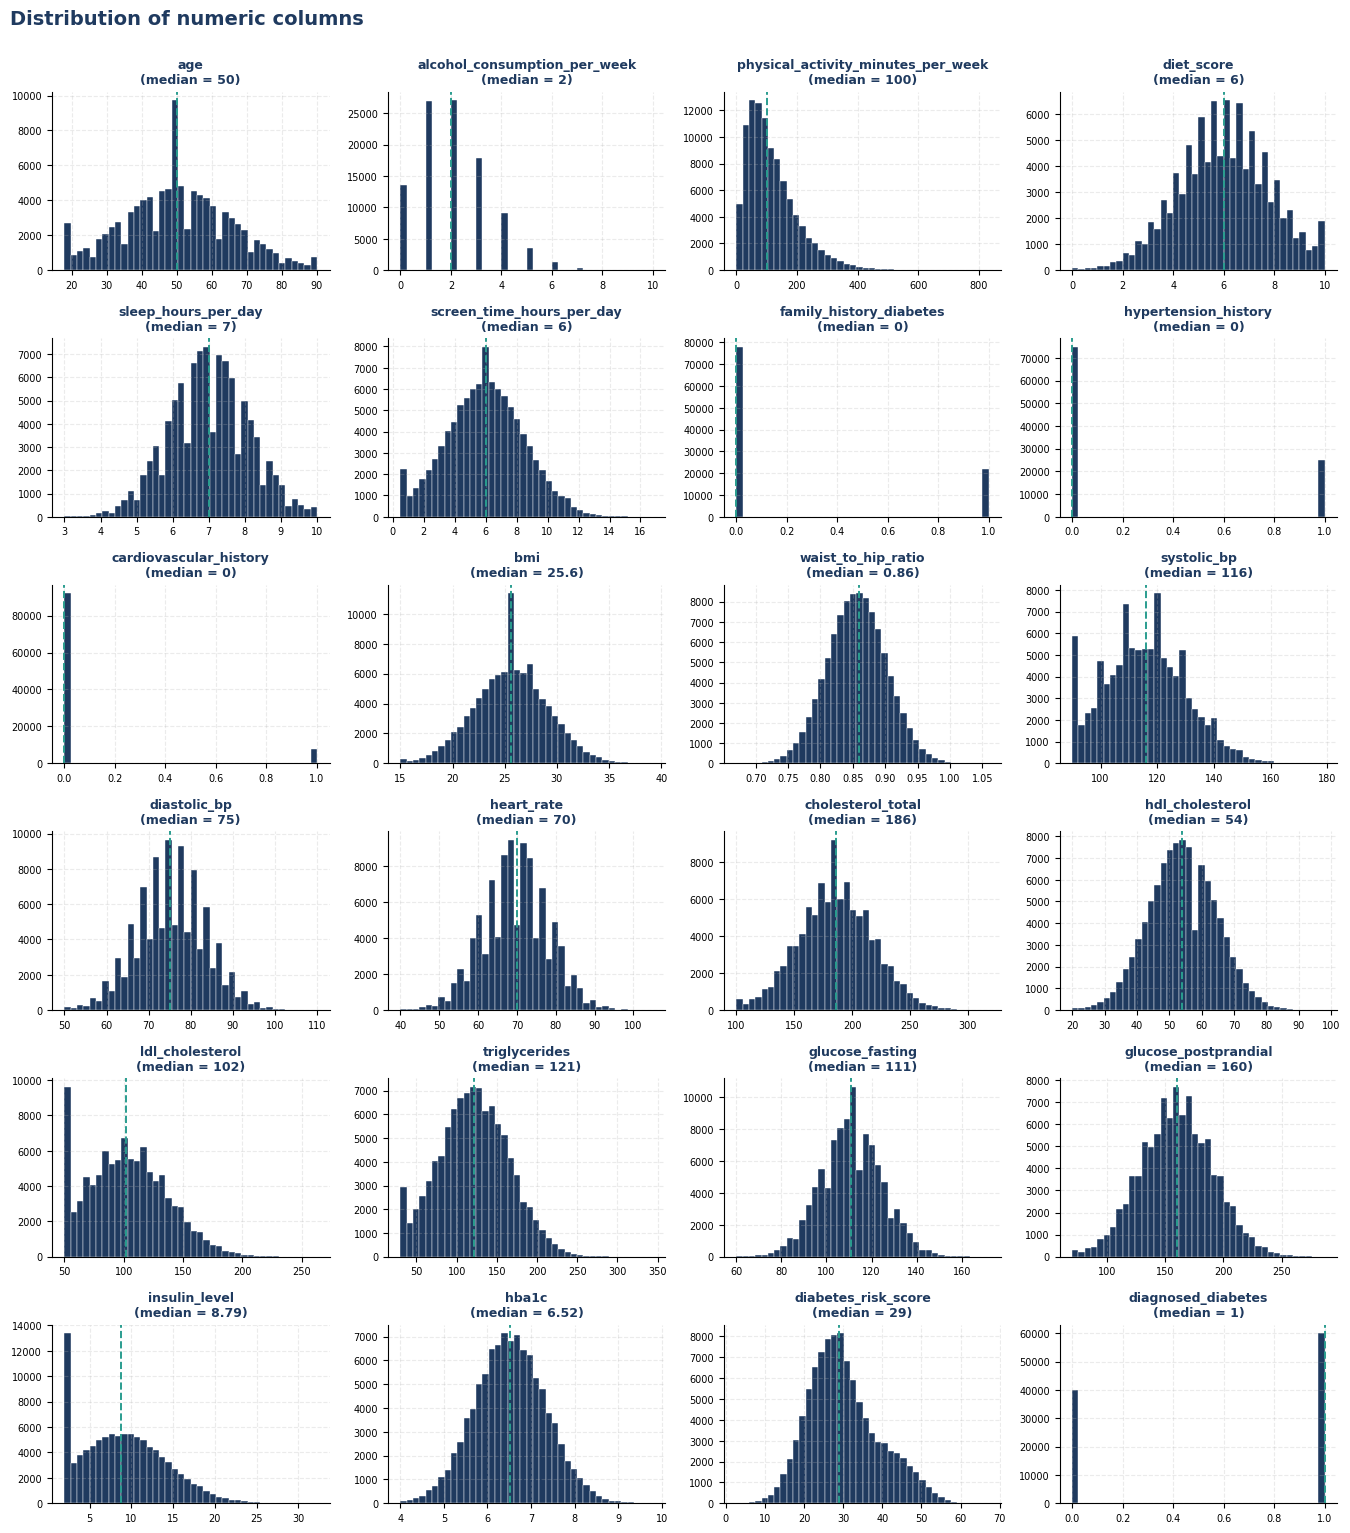

In [12]:
plot_numeric_histograms(df)

In [13]:
df.isna().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [14]:
# The non-numeric columns we want to see the distribution of
CATEGORICAL_COLS = ["gender", "ethnicity", "education_level",
                    "income_level", "employment_status", "smoking_status"]


def plot_categorical_bars(df, columns=CATEGORICAL_COLS, ncols=3, save_path=None, dpi=130):
    """Bar chart of value counts for each categorical column."""
    nrows = math.ceil(len(columns) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2))
    axes = np.atleast_1d(axes).ravel()

    for ax, col in zip(axes, columns):          # <-- list + for loop, as asked
        counts = df[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color=NAVY)
        ax.set_title(col, fontsize=10, color=NAVY, fontweight="bold")
        ax.tick_params(axis="x", labelrotation=30, labelsize=8)

    for ax in axes[len(columns):]:
        ax.set_visible(False)

    fig.suptitle("Distribution of categorical columns", fontsize=14,
                 fontweight="bold", color=NAVY, x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved {len(columns)} bar charts -> {save_path}")
    return fig

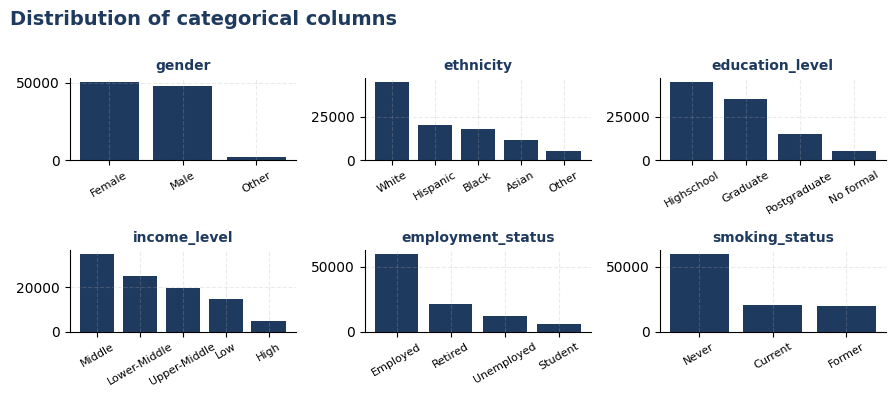

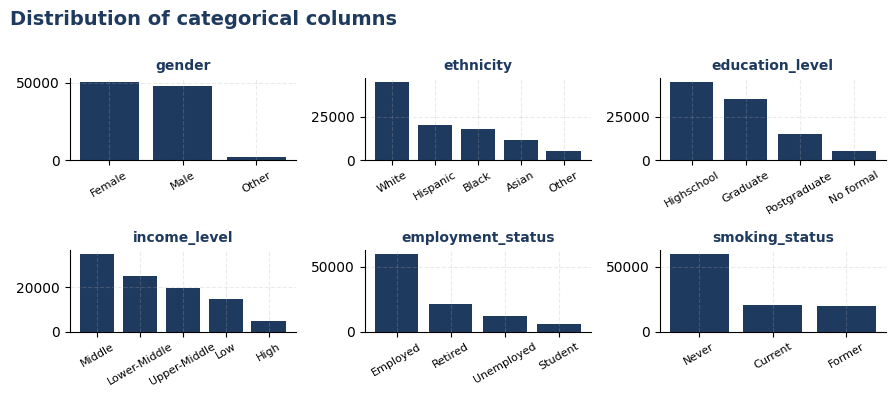

In [15]:
plot_categorical_bars(df)

### Type 1 Diabetes and Gestational Diabetes are very rare as we discussed above hence we will not see much cases in this dataset. They also very rare in real world so we could drop it when working on this model.

<Axes: >

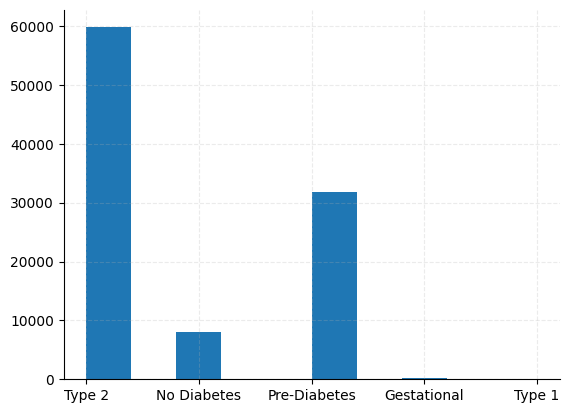

In [16]:
df['diabetes_stage'].hist()

In [17]:
from matplotlib.lines import Line2D

# The stage order for the metabolic continuum (ordinal: healthy -> worst)
CONTINUUM_ORDER = ["No Diabetes", "Pre-Diabetes", "Type 2"]
# Sequential shades to reinforce the ordering (light -> dark)
STAGE_COLORS = ["#a8c5dd", "#5b8db8", "#1f3a5f"]
# Qualitative palette for grouped series (blue / orange / grey), like the ref
SERIES_COLORS = ["#4a90c2", "#e8863c", "#9aa0a6", "#6ab187", "#b23c56"]
ORANGE = "#e8863c"


def _clean_bar_axis(ax):
    """Reference look: horizontal gridlines only, no top/right/left spines."""
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="#d9d9d9", linewidth=0.8)
    ax.xaxis.grid(False)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)


def plot_risk_factors_by_stage(
    df,
    numeric=("age", "bmi", "waist_to_hip_ratio",
             "physical_activity_minutes_per_week", "diet_score", 'diabetes_risk_score'),
    binary=("family_history_diabetes", "hypertension_history",
            "cardiovascular_history"),
    stage_col="diabetes_stage",
    order=CONTINUUM_ORDER,
    ncols=4,
    show_error=False,
    save_path=None,
    dpi=130,
):
    """
    Bar-chart panel of risk factors across the ordinal stages.

    NUMERIC factor -> bar of the MEAN per stage (optionally +/- 1 std).
    BINARY factor  -> bar of the proportion == 1 per stage.
    Each factor gets its own subplot (so different scales are fine); bars are
    shaded light -> dark to reinforce the healthy -> worst ordering.

    show_error : if True, draw +/- 1 std whiskers on numeric bars. Off by default
                 to match a clean bar-chart look, but bars DO hide spread, so
                 flip it on when effect size matters.
    """
    sub = df[df[stage_col].isin(order)]
    factors = list(numeric) + list(binary)
    n = len(factors)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 3.1))
    axes = np.atleast_1d(axes).ravel()
    x = np.arange(len(order))

    for ax, col in zip(axes, factors):
        if col in numeric:
            means = [sub.loc[sub[stage_col] == s, col].mean() for s in order]
            errs = ([sub.loc[sub[stage_col] == s, col].std() for s in order]
                    if show_error else None)
            ax.bar(x, means, color=STAGE_COLORS, width=0.6,
                   yerr=errs, capsize=3, error_kw=dict(elinewidth=1, ecolor="#666"))
            for i, m in enumerate(means):
                ax.text(i, m, f"{m:.1f}", ha="center", va="bottom", fontsize=7)
        else:  # binary -> proportion
            props = [sub.loc[sub[stage_col] == s, col].mean() for s in order]
            ax.bar(x, props, color=STAGE_COLORS, width=0.6)
            ax.set_ylabel("proportion = 1", fontsize=7)
            for i, p in enumerate(props):
                ax.text(i, p, f"{p:.1%}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(order, rotation=20, fontsize=7)
        ax.set_title(col, fontsize=9, color=NAVY, fontweight="bold")
        ax.tick_params(axis="y", labelsize=7)
        _clean_bar_axis(ax)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle("Risk factors across the diabetes continuum (No Diabetes -> Pre -> Type 2)",
                 fontsize=13, fontweight="bold", color=NAVY, x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved risk-factor panel -> {save_path}")
    plt.close(fig)
    return fig


def plot_grouped_bars_by_stage(
    df,
    factors=("family_history_diabetes", "hypertension_history",
             "cardiovascular_history"),
    stage_col="diabetes_stage",
    order=CONTINUUM_ORDER,
    normalize=True,
    ncols=3,
    colors=STAGE_COLORS,
    save_path=None,
    dpi=130,
):
    """
    Grouped bar chart per binary factor: x-axis is the factor value (0 / 1),
    and within each group there is one bar per stage showing the COUNT of rows
    in that stage. One subplot per factor.

    normalize : if True, show the proportion of each stage WITHIN each 0/1 group
                instead of the raw count (useful because the groups differ in size).
    """
    sub = df[df[stage_col].isin(order)]
    n = len(factors)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.8))
    axes = np.atleast_1d(axes).ravel()
    width = 0.8 / len(order)

    for ax, col in zip(axes, factors):
        # counts of each stage within each value of the binary factor
        ct = pd.crosstab(sub[col], sub[stage_col]).reindex(columns=order, fill_value=0)
        if normalize:
            ct = ct.div(ct.sum(axis=1), axis=0)
        groups = ct.index.tolist()                 # e.g. [0, 1]
        x = np.arange(len(groups))

        for j, stage in enumerate(order):
            heights = ct[stage].values
            offset = (j - (len(order) - 1) / 2) * width
            bars = ax.bar(x + offset, heights, width, label=stage, color=colors[j])
            for b, v in zip(bars, heights):
                label = f"{v:.0%}" if normalize else f"{int(v):,}"
                ax.text(b.get_x() + b.get_width() / 2, v, label,
                        ha="center", va="bottom", fontsize=7, color="#333")

        ax.set_xticks(x)
        ax.set_xticklabels(groups, fontsize=10)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("proportion" if normalize else "count", fontsize=8)
        ax.set_title(col, fontsize=10, color=NAVY, fontweight="bold")
        _clean_bar_axis(ax)

    for ax in axes[n:]:
        ax.set_visible(False)

    # one shared legend (stages) for the whole figure
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[j]) for j in range(len(order))]
    fig.legend(handles, order, frameon=False, fontsize=9, ncol=len(order),
               loc="upper left", bbox_to_anchor=(0.01, 1.0))
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved grouped bar chart -> {save_path}")
    plt.close(fig)
    return fig

### A clear gradient emerges when we stratify by `family_history_diabetes`. Among patients with a positive family history, 78% have been diagnosed with type 2 diabetes, 20% present as pre-diabetic, and only 2% show no diabetes. In contrast, among patients without a family history, the type 2 diabetes rate drops to 55%, pre-diabetes rises slightly to 35%, and 10% show no diabetes. This pattern — a markedly higher prevalence of diabetes and pre-diabetes among those with a family history — is consistent with the well-established heritability of type 2 diabetes, and suggests the dataset reflects clinically plausible signal rather than noise.

### However, the remaining category does not contain much information about whether a person will get diabetes or not if we just based on it.

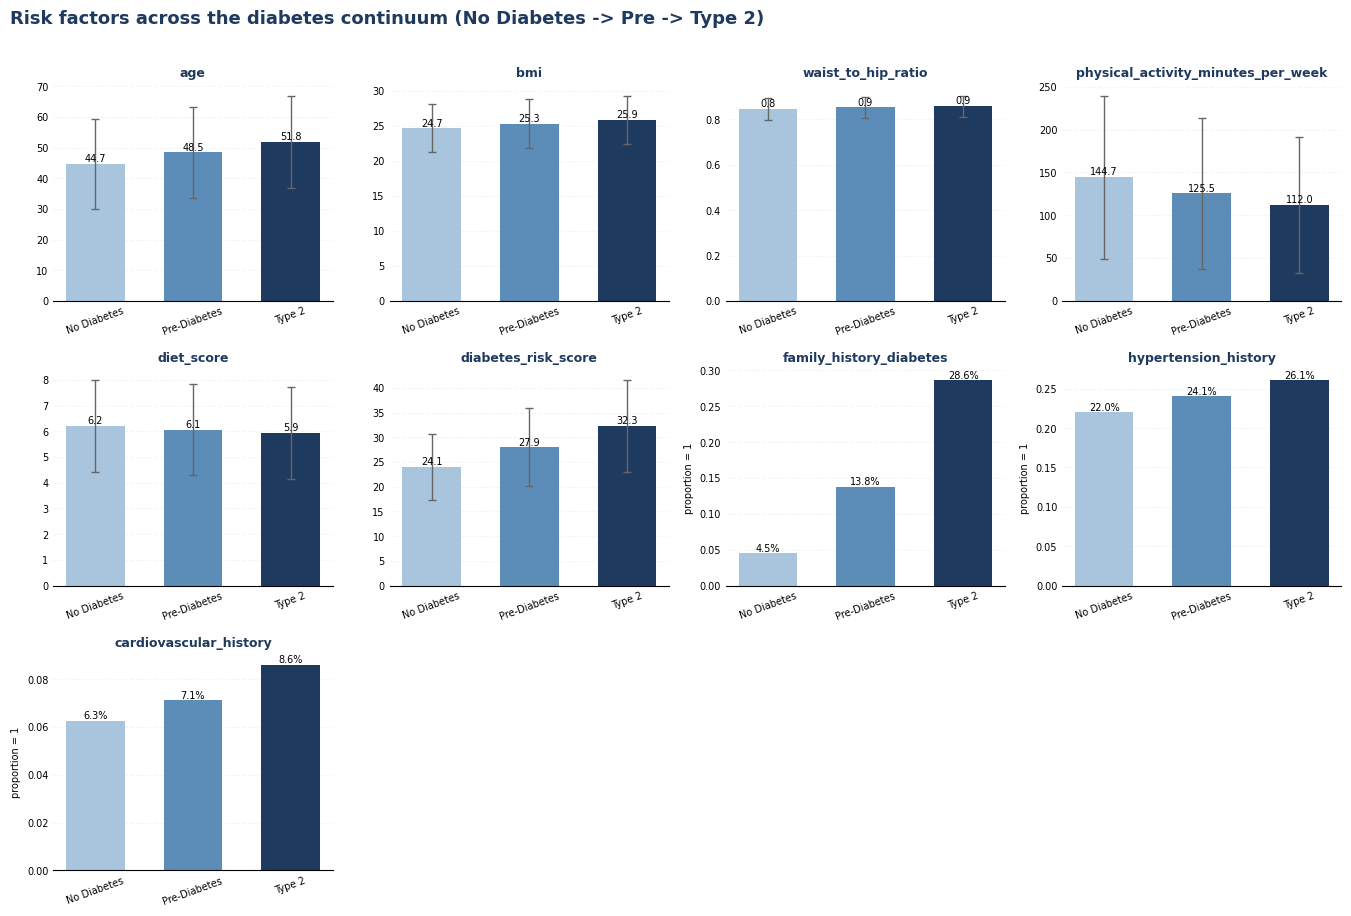

In [18]:
plot_risk_factors_by_stage(df, show_error=True)

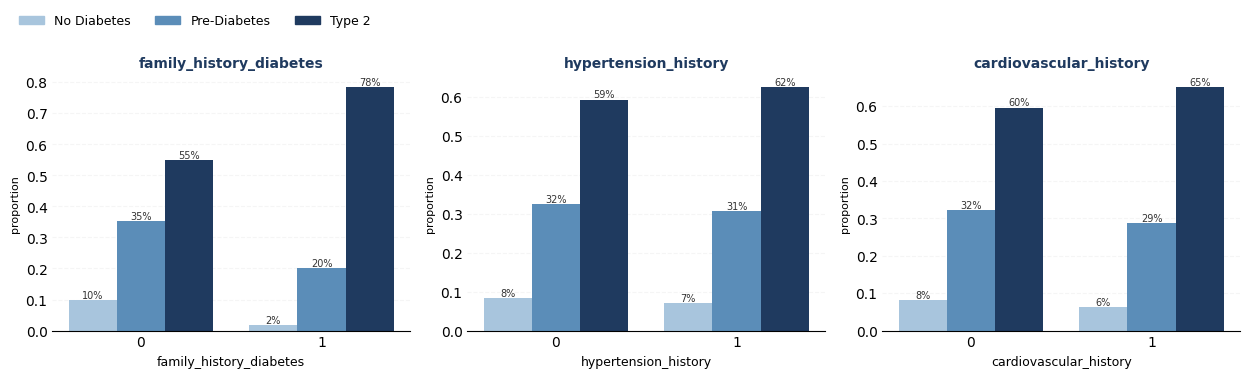

In [19]:
plot_grouped_bars_by_stage(df)

### As discussed above, Type 1 and Gestational diabetes are both clinically rare and correspondingly underrepresented in this dataset, together accounting for only about 0.4% of all records (122 Type 1 cases and 278 Gestational cases out of 100,000). Beyond simple rarity, these two forms also arise through different biological mechanisms than the ones this dataset is built to capture: Type 1 is an autoimmune condition where the body attacks its own insulin-producing cells, and Gestational diabetes is triggered specifically by pregnancy. Neither follows the insulin-resistance pathway, driven by factors like weight, activity, and family history, that the rest of our features are designed to measure. Including them would ask the model to predict two different diseases using signals that were never meant to explain them.

In [20]:
df.drop(df[df['diabetes_stage'] == 'Type 1'].index, inplace=True)
df.drop(df[df['diabetes_stage'] == 'Gestational'].index, inplace=True)
df['diabetes_stage'] = df['diabetes_stage'].map({'No Diabetes': 0, 'Pre-Diabetes': 1,'Type 2': 2})

# Check correlation
print(df[['diagnosed_diabetes', 'diabetes_risk_score', 'diabetes_stage']].corr())

                     diagnosed_diabetes  diabetes_risk_score  diabetes_stage
diagnosed_diabetes             1.000000             0.277131        0.918516
diabetes_risk_score            0.277131             1.000000        0.297553
diabetes_stage                 0.918516             0.297553        1.000000


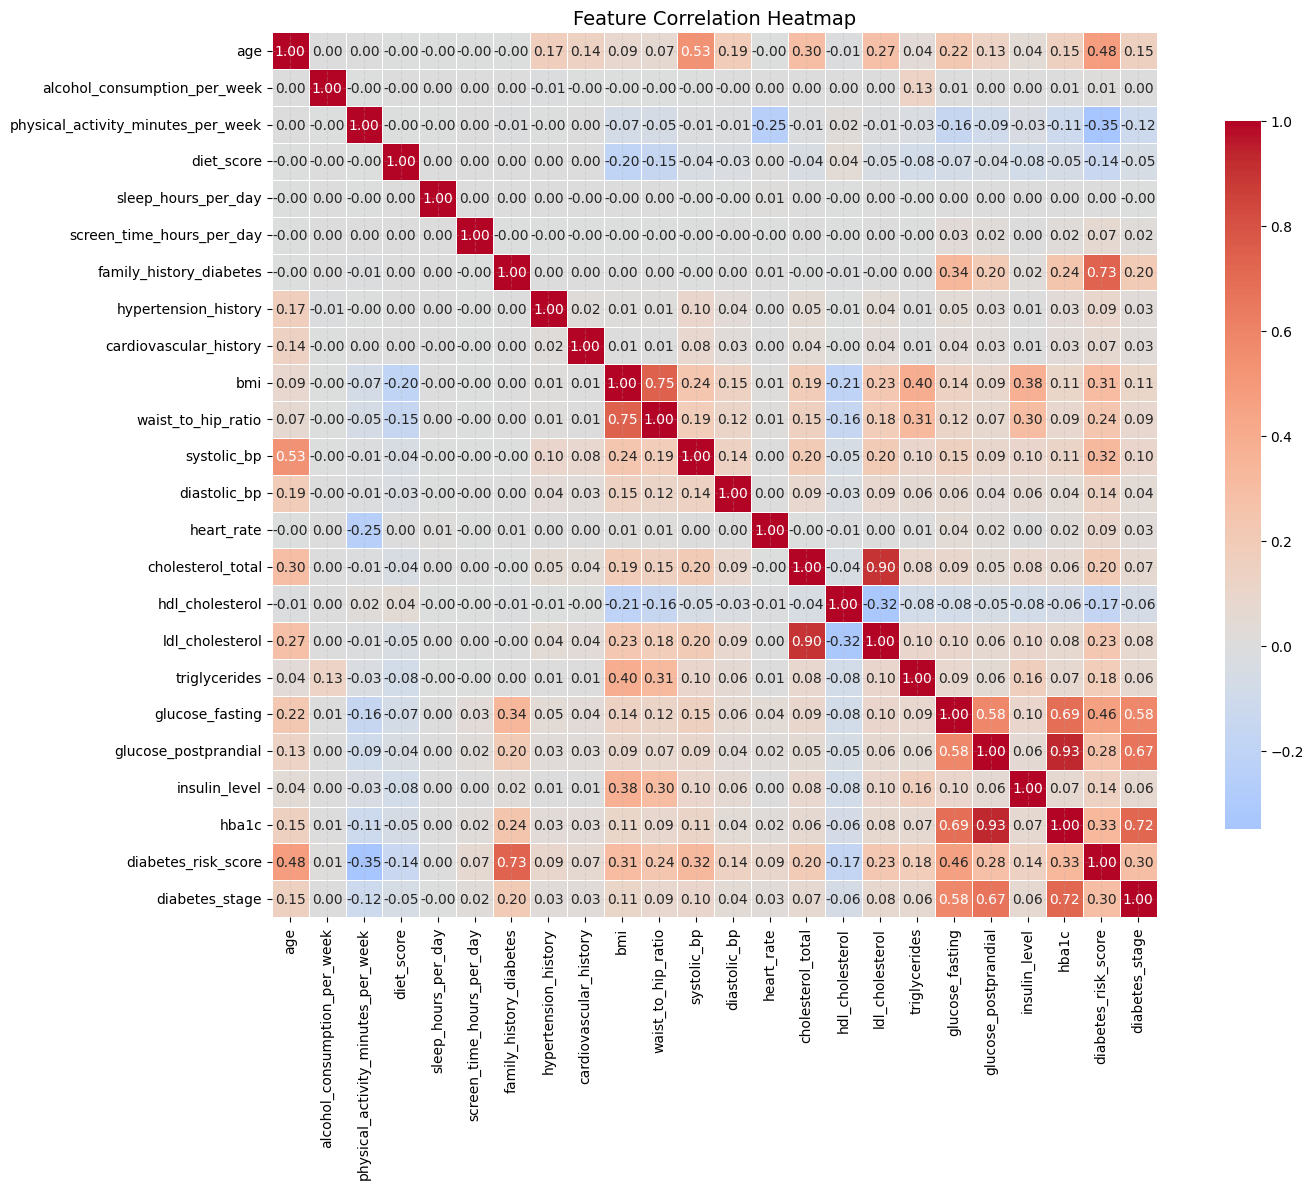

In [21]:
cols = ['age','alcohol_consumption_per_week','physical_activity_minutes_per_week', 'diet_score',
        'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes',
        'hypertension_history','cardiovascular_history', 'bmi', 'waist_to_hip_ratio',
        'systolic_bp','diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
        'ldl_cholesterol', 'triglycerides', 'glucose_fasting','glucose_postprandial',
        'insulin_level', 'hba1c', 'diabetes_risk_score','diabetes_stage']

# Copy and encode diabetes_stage if it's categorical/string
df_corr = df[cols].copy()
if df_corr['diabetes_stage'].dtype == 'object' or df_corr['diabetes_stage'].dtype.name == 'category':
    df_corr['diabetes_stage'] = df_corr['diabetes_stage'].astype('category').cat.codes

corr_matrix = df_corr.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Reading the correlation heatmap
* The heatmap separates the features into three clear tiers with respect to `diabetes_stage`.
* The strongest correlation is a warning sign, not a win. `diagnosed_diabetes` correlates with the target at roughly 0.92, which is almost perfect. That is not a useful predictor; it is very nearly the label itself, recorded under a different name. Including it would let the model "predict" the diagnosis by simply reading the diagnosis, so we drop it in the next step.
* The genuine signal sits in the `glucose` and `HbA1c` block. After `diagnosed_diabetes`, the next strongest features are hba1c (0.72), `glucose_postprandial` (0.67), and `glucose_fasting` (0.58). These are the direct metabolic markers of diabetes, so their strength is expected and clinically real. Notice, though, that they are also heavily correlated with each other (HbA1c and fasting glucose sit around 0.69), meaning they carry overlapping information rather than four independent signals. This block is doing most of the predictive work, and it foreshadows the leakage discussion later: these are all values that only exist after a blood draw. `diabetes_risk_score` (0.30) is a weaker composite that partly overlaps this same block.
* Everything else is individually weak. `family_history_diabetes` (0.20) and age (0.15) are the strongest of the lifestyle and demographic features, and the rest fall below 0.15, with several (sleep, alcohol, heart rate) essentially at zero. As discussed earlier, low linear correlation does not automatically mean a feature is useless, since a tree model can still exploit non-linear effects and interactions. But it does tell us that no single lifestyle variable comes close to the lab markers, and that any model built without the labs will be working from much fainter signal.

### We want to drop the `diagnosed_diabetes` column because it's similar to the target column which is `diabetes_stages`

In [22]:
df.drop(columns=['diagnosed_diabetes'], inplace=True)

### Drop the rows where `systolic_blood_pressure` > `diastolic_blood_pressure` because it is impossible in real life.

### Also we will drop rows that have `ldl_cholesterol` + `hdl_cholesterol` > `cholesterol_total` because this condition is also not true in real life.

In [23]:
df = df[df['systolic_bp'] > df['diastolic_bp']].reset_index(drop=True)
df = df[df['ldl_cholesterol'] + df['hdl_cholesterol'] < df['cholesterol_total']].reset_index(drop=True)

In [24]:
df.shape

(98120, 30)

In [ ]:
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_stage
0,58.0,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215.0,5.7,...,68,239.0,41,160,145,136.0,236,6.36,8.18,Type 2
1,48.0,Female,White,Highschool,Middle,Employed,Former,1,143.0,6.7,...,67,116.0,55,50,30,93.0,150,2.00,5.63,No Diabetes
2,60.0,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57.0,6.4,...,74,213.0,66,99,36,118.0,195,5.07,7.51,Type 2
3,74.0,Female,Black,Highschool,Low,Retired,Never,0,49.0,3.4,...,68,171.0,50,79,140,139.0,253,5.28,9.03,Type 2
4,46.0,Male,White,Graduate,Middle,Retired,Never,1,109.0,7.2,...,67,210.0,52,125,160,137.0,184,12.74,7.20,Type 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98506,46.0,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136.0,8.3,...,63,227.0,45,150,116,113.0,109,14.58,5.55,Pre-Diabetes
98507,50.0,Female,White,Graduate,Middle,Employed,Never,3,76.0,8.8,...,57,207.0,55,123,146,96.0,146,9.02,5.97,Pre-Diabetes
98508,57.0,Female,Black,No formal,Upper-Middle,Employed,Former,4,121.0,9.9,...,69,189.0,50,111,184,93.0,132,2.57,5.21,No Diabetes
98509,47.0,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52.0,5.9,...,58,173.0,68,91,116,106.0,117,9.81,5.53,Pre-Diabetes


### We want to drop the rows that contained `gender` = Other because realistically, there are only 2 type of genders.

In [49]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)

### Since Machine Learning only work on numbers hence we want to convert `male` = 1, and `female` = 0

In [50]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

### One Hot encoder

In [51]:
category_columns = ['ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
df_encoded = pd.get_dummies(df, columns=category_columns)

In [52]:
df_encoded.head()

,age,gender,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,...,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Current,smoking_status_Former,smoking_status_Never
0,58.0,1,0,215.0,5.7,7.9,7.9,0,0,0,...,True,False,False,True,False,False,False,False,False,True
1,48.0,0,1,143.0,6.7,6.5,8.7,0,0,0,...,False,True,False,True,False,False,False,False,True,False
2,60.0,1,1,57.0,6.4,10.0,8.1,1,0,0,...,False,True,False,False,False,False,True,False,False,True
3,74.0,0,0,49.0,3.4,6.6,5.2,0,0,0,...,False,False,False,False,True,False,False,False,False,True
4,46.0,1,1,109.0,7.2,7.4,5.0,0,0,0,...,False,True,False,False,True,False,False,False,False,True


In [53]:
df_encoded['diabetes_stage'].unique()

array([2, 0, 1])

### Models (RandomForest, XGBoost, Logistics Regresion)
#### Even though RandomForest and XGBoost do not require us to scale the feature but we need to do StandardScaler() to make sure all the features are in the same scale before we can feed the data into Logistics Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

target = 'diabetes_stage'

# Numeric columns to scale (exclude target and binary/dummy columns)
num_cols = [
    c for c in df_encoded.select_dtypes('number').columns
    if c != target and df_encoded[c].nunique() > 2
]

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Split BEFORE scaling to avoid leaking test statistics
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,          # keep class ratios identical in train & test
)

# Fit on train only, then apply the same transform to test
scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols]  = scaler.transform(X_test[num_cols])

### Logistics Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.8187444739168878


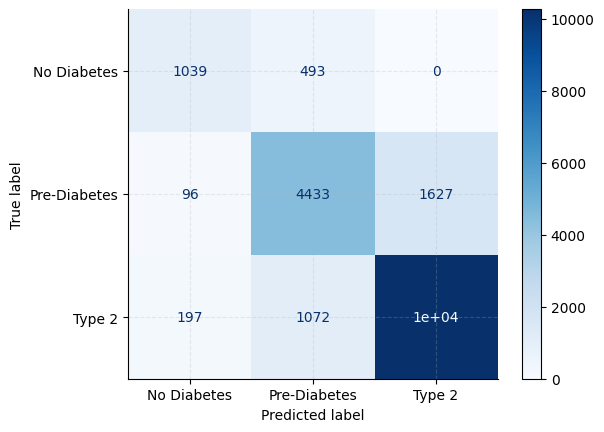

              precision    recall  f1-score   support

           0      0.780     0.678     0.726      1532
           1      0.739     0.720     0.729      6156
           2      0.863     0.890     0.876     11539

    accuracy                          0.819     19227
   macro avg      0.794     0.763     0.777     19227
weighted avg      0.817     0.819     0.817     19227



In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=300)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Pre-Diabetes", "Type 2"])
disp.plot(cmap=plt.cm.Blues)

# Display the plot
plt.show()
print(classification_report(y_test, predictions, digits=3))

### Random Forest

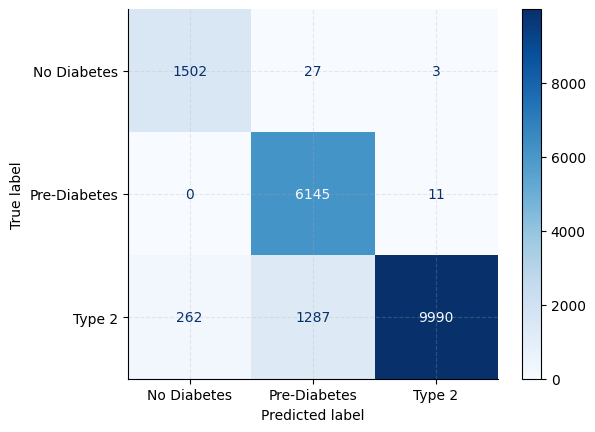

Accuracy: 0.9173037915431425
              precision    recall  f1-score   support

           0      0.851     0.980     0.911      1532
           1      0.824     0.998     0.903      6156
           2      0.999     0.866     0.927     11539

    accuracy                          0.917     19227
   macro avg      0.891     0.948     0.914     19227
weighted avg      0.931     0.917     0.918     19227



In [56]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
random_forest_model.fit(X_train, y_train)

predictions = random_forest_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Pre-Diabetes", "Type 2"])
disp.plot(cmap=plt.cm.Blues)

# Display the plot
plt.show()

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions, digits=3))

### Xgboost

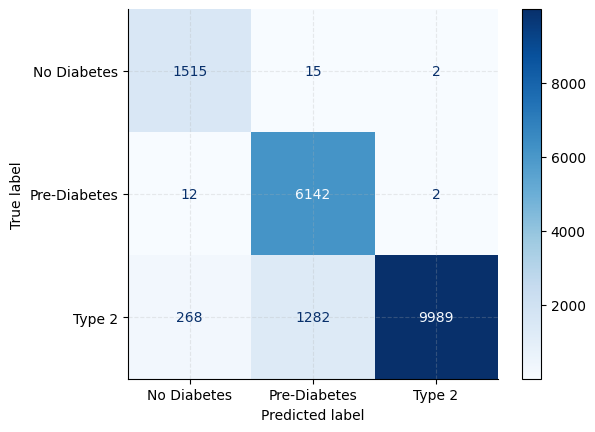

XGBoost Accuracy: 0.9177718832891246
              precision    recall  f1-score   support

           0      0.844     0.989     0.911      1532
           1      0.826     0.998     0.904      6156
           2      1.000     0.866     0.928     11539

    accuracy                          0.918     19227
   macro avg      0.890     0.951     0.914     19227
weighted avg      0.932     0.918     0.919     19227



In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_preds = xgb_model.predict(X_test)

cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Pre-Diabetes", "Type 2"])
disp.plot(cmap=plt.cm.Blues)

# Display the plot
plt.show()

print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds)}")

print(classification_report(y_test, xgb_preds, digits=3))

In [58]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                               Feature  Importance
22                               hba1c    0.753993
19                     glucose_fasting    0.132256
23                 diabetes_risk_score    0.007847
29            education_level_Graduate    0.003370
26                  ethnicity_Hispanic    0.003162
36                 income_level_Middle    0.003073
44                smoking_status_Never    0.003051
41        employment_status_Unemployed    0.003007
31           education_level_No formal    0.002985
40           employment_status_Student    0.002866
42              smoking_status_Current    0.002829
33                   income_level_High    0.002810
39           employment_status_Retired    0.002810
43               smoking_status_Former    0.002754
0                                  age    0.002732
21                       insulin_level    0.002722
28                     ethnicity_White    0.002703
4                           diet_score    0.002664
25                     ethnicit

# Cross-Validation

In [59]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

# stratified folds preserve the class ratios in every fold (critical with imbalance)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)
SCORING = "f1_macro"   # tune for macro-F1, NOT accuracy

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    "n_estimators":     [100, 150, 200],
    "max_depth":        [None, 10, 15, 20],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2"],
    "class_weight":     [None, "balanced", "balanced_subsample"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=2026, n_jobs=-1),
    rf_grid, n_iter=10, scoring=SCORING, cv=cv,
    random_state=42, n_jobs=-1, verbose=1,
).fit(X_train, y_train)

print("RF best macro-F1 (cv):", round(rf_search.best_score_, 3))
print("RF best params:", rf_search.best_params_)
print(classification_report(y_test, rf_search.predict(X_test), digits=3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF best macro-F1 (cv): 0.915
RF best params: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced_subsample'}
              precision    recall  f1-score   support

         0.0      0.850     0.986     0.913      1532
         1.0      0.825     1.000     0.904      6156
         2.0      1.000     0.865     0.928     11539

    accuracy                          0.918     19227
   macro avg      0.892     0.951     0.915     19227
weighted avg      0.932     0.918     0.919     19227



In [ ]:
from xgboost import XGBClassifier

xgb_grid = {
    "n_estimators":     [150, 200, 300],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.3],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric="mlogloss"),
    xgb_grid, n_iter=15, scoring=SCORING, cv=cv,
    random_state=42, n_jobs=-1, verbose=1,
).fit(X_train, y_train)

print("XGB best macro-F1 (cv):", round(xgb_search.best_score_, 3))
print("XGB best params:", xgb_search.best_params_)
print(classification_report(y_test, xgb_search.predict(X_test), digits=3))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGB best macro-F1 (cv): 0.915
XGB best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

         0.0      0.844     0.989     0.911      1532
         1.0      0.825     0.998     0.904      6156
         2.0      1.000     0.865     0.928     11539

    accuracy                          0.918     19227
   macro avg      0.890     0.951     0.914     19227
weighted avg      0.932     0.918     0.919     19227



In [60]:
from sklearn.linear_model import LogisticRegression

lr_grid = {"C": [0.01, 0.1, 1, 10], "class_weight": [None, "balanced"]}
lr_search = GridSearchCV(
    LogisticRegression(solver="lbfgs", max_iter=1000),
    lr_grid, scoring=SCORING, cv=cv, n_jobs=-1,
).fit(X_train, y_train)

print("LR best macro-F1 (cv):", round(lr_search.best_score_, 3))
print("LR best params:", lr_search.best_params_)
print(classification_report(y_test, lr_search.predict(X_test), digits=3))

LR best macro-F1 (cv): 0.831
LR best params: {'C': 10, 'class_weight': 'balanced'}
              precision    recall  f1-score   support

           0      0.639     0.930     0.758      1532
           1      0.796     0.838     0.817      6156
           2      0.950     0.865     0.906     11539

    accuracy                          0.862     19227
   macro avg      0.795     0.878     0.827     19227
weighted avg      0.876     0.862     0.865     19227



### Across the three models evaluated, both XGBoost and Random Forest substantially outperform Logistic Regression, with F1-scores above 0.90 for all three classes (no diabetes, pre-diabetes, type 2) even before and after the Cross-Validation.
### Logistic Regression, by contrast, shows a clear drop-off on the earlier disease stages — F1 of 0.758 for no-diabetes and 0.817 for pre-diabetes, compared to 0.900 for type 2, meaning it's most reliable at identifying confirmed type 2 cases, but least reliable at distinguishing a healthy patient from an early, pre-diabetic one. Clinically, this is a meaningful distinction: confusion between no-diabetes and pre-diabetes is generally less dangerous than missing a type 2 diagnosis outright, since it would typically prompt closer monitoring rather than a missed critical diagnosis. Still, given that early detection is often where intervention has the most impact, this weakness is not one we want to accept if a better-performing alternative is available.
### While Logistic Regression trains considerably faster, training time is a secondary concern for a medical prediction problem: XGBoost and Random Forest's consistently high, balanced performance across all classes makes them the stronger choice here.

In [ ]:
def fold_scores(search):
    """Per-fold macro-F1 for the best candidate in a fitted search."""
    r = search.cv_results_
    bi = search.best_index_
    k = search.cv.get_n_splits()
    return np.array([r[f"split{i}_test_score"][bi] for i in range(k)])

rf_folds  = fold_scores(rf_search)
xgb_folds = fold_scores(xgb_search)

print("fold-by-fold macro-F1 (same stratified splits):")
for i, (r, x) in enumerate(zip(rf_folds, xgb_folds)):
    winner = "XGB" if x > r else "RF "
    print(f"  fold {i}:  RF={r:.4f}   XGB={x:.4f}   -> {winner}")

print(f"\nRF   mean={rf_folds.mean():.4f}  std={rf_folds.std():.4f}")
print(f"XGB  mean={xgb_folds.mean():.4f}  std={xgb_folds.std():.4f}")
print(f"\nXGB beats RF in {int((xgb_folds > rf_folds).sum())} of {len(rf_folds)} folds")
print(f"mean gap (XGB - RF): {xgb_folds.mean() - rf_folds.mean():+.4f}")

fold-by-fold macro-F1 (same stratified splits):
  fold 0:  RF=0.9161   XGB=0.9144   -> RF 
  fold 1:  RF=0.9151   XGB=0.9158   -> XGB
  fold 2:  RF=0.9137   XGB=0.9145   -> XGB

RF   mean=0.9150  std=0.0010
XGB  mean=0.9149  std=0.0006

XGB beats RF in 2 of 3 folds
mean gap (XGB - RF): -0.0001


### The feature importance rankings from XGBoost tell a clinically unsurprising story: `hba1c` dominates with an importance score of 0.75, followed distantly by `glucose_fasting` at 0.13, with every remaining feature contributing less than 0.008. In practical terms, this means the model has essentially learned to diagnose diabetes the same way an endocrinologist would — off a single lab value.
### This makes complete physiological sense. HbA1c measures the percentage of hemoglobin that has become glycated — permanently bound to glucose — over the roughly 2–3 month lifespan of a red blood cell. Because this binding is cumulative and irreversible, HbA1c functions as a biological record of average blood glucose over the preceding months, which is precisely why it's the diagnostic gold standard rather than just another correlate of diabetes. Clinically, HbA1c below 5.7% is considered normal, 5.7–6.4% is classified as prediabetes, and 6.5% or higher meets the threshold for a type 2 diabetes diagnosis — which maps almost exactly onto our three target classes. In other words, the model isn't really predicting diabetes_stage so much as re-deriving the same thresholds a clinician would use to assign it in the first place, just recovered statistically instead of by rule.
### That's exactly the problem for our use case. HbA1c isn't something a patient can self-report or estimate from lifestyle factors — it only exists after a blood draw. A model that leans almost entirely on a lab-confirmed diagnostic marker to predict the diagnosis it's already measuring isn't adding predictive value; it's just re-deriving the answer from a value that's already close to the answer. If our goal is a model useful for early risk screening — flagging at-risk individuals before they've had a diagnostic lab test — then hba1c is closer to leakage than a genuine feature, and we should drop it and re-train. We'd expect performance to fall once it's removed, precisely because we're forcing the model to work from indirect, pre-diagnostic signals instead of the diagnostic result itself — which is the harder, but clinically more useful, task.

### Models without hba1c

In [71]:
df_no_hba1c = df_encoded.drop(columns=['hba1c'])

X_no_hba1c = df_no_hba1c.drop(columns=[target])
y_no_hba1c = df_no_hba1c[target]

In [72]:
X_train_no_hba1c, X_test_no_hba1c, y_train_no_hba1c, y_test_no_hba1c = train_test_split(
    X_no_hba1c, y_no_hba1c,
    test_size=0.2,
    random_state=2026,
    stratify=y_no_hba1c,          # keep class ratios identical in train & test
)

### As expected, removing `hba1c` caused a measurable drop in performance across all three classes. Overall accuracy fell from 0.91 to 0.83, and F1-scores declined to 0.784, 0.763, and 0.87 for Class 0, Class 1, and Class 2 respectively. This confirms our earlier hypothesis: a substantial portion of the model's original performance was being driven by a single diagnostic lab value rather than by genuine predictive signal from patient characteristics.
### With `hba1c` removed, the feature importance rankings shift meaningfully. `glucose_postprandial` now leads at 0.46, followed by `glucose_fasting` at 0.23, with `diabetes_risk_score` contributing 0.022. While the resulting accuracy and F1-scores are lower than before, this is arguably a more honest and clinically useful model. Fasting and postprandial glucose are far more accessible than HbA1c: fasting glucose can be measured with a simple glucometer after an overnight fast, and postprandial glucose is captured the same way after a meal, without the specialized lab processing HbA1c requires. Combined with the earlier finding that `family_history_diabetes` correlates strongly with `diabetes_risk_score`, this suggests a practical screening model: even without a full HbA1c panel, a combination of glucose readings and family history could still support a reasonably confident risk assessment.

In [73]:
from xgboost import XGBClassifier

xgb_model_no_hba1c = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model_no_hba1c.fit(X_train_no_hba1c, y_train_no_hba1c)

# Predict and evaluate
xgb_preds_no_hba1c = xgb_model_no_hba1c.predict(X_test_no_hba1c)

cm_no_hba1c = confusion_matrix(y_test_no_hba1c, xgb_preds_no_hba1c)
disp_no_hba1c = ConfusionMatrixDisplay(confusion_matrix=cm_no_hba1c, display_labels=["No Diabetes", "Pre-Diabetes", "Type 2"])
# disp.plot(cmap=plt.cm.Blues)

# Display the plot
plt.show()

print(f"XGBoost Accuracy: {accuracy_score(y_test_no_hba1c, xgb_preds_no_hba1c)}")

print(classification_report(y_test_no_hba1c, xgb_preds_no_hba1c, digits=3))

XGBoost Accuracy: 0.826077911270609
              precision    recall  f1-score   support

           0      0.741     0.833     0.784      1532
           1      0.722     0.808     0.763      6156
           2      0.907     0.835     0.870     11539

    accuracy                          0.826     19227
   macro avg      0.790     0.825     0.805     19227
weighted avg      0.835     0.826     0.829     19227



In [74]:
importance_df_no_hba1c = pd.DataFrame({
    'Feature': X_train_no_hba1c.columns,
    'Importance': xgb_model_no_hba1c.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df_no_hba1c)

                               Feature  Importance
20                glucose_postprandial    0.456323
19                     glucose_fasting    0.228997
22                 diabetes_risk_score    0.022286
27                     ethnicity_White    0.009664
30           education_level_No formal    0.009533
33                    income_level_Low    0.009253
43                smoking_status_Never    0.009114
39           employment_status_Student    0.008551
41              smoking_status_Current    0.008426
23                     ethnicity_Asian    0.008239
34           income_level_Lower-Middle    0.008163
11                  waist_to_hip_ratio    0.008014
38           employment_status_Retired    0.008003
17                     ldl_cholesterol    0.007594
36           income_level_Upper-Middle    0.007562
3   physical_activity_minutes_per_week    0.007429
0                                  age    0.007366
37          employment_status_Employed    0.007334
13                        diast

In [75]:
xgb_grid_no_hba1c = {
    "n_estimators":     [150, 200, 300],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.3],
}
xgb_search_no_hba1c = RandomizedSearchCV(
    XGBClassifier(random_state=2026, n_jobs=-1, eval_metric="mlogloss"),
    xgb_grid_no_hba1c, n_iter=15, scoring=SCORING, cv=cv,
    random_state=2026, n_jobs=-1, verbose=1,
).fit(X_train_no_hba1c, y_train_no_hba1c)

print("XGB best macro-F1 (cv):", round(xgb_search_no_hba1c.best_score_, 3))
print("XGB best params:", xgb_search_no_hba1c.best_params_)
print(classification_report(y_test_no_hba1c, xgb_search_no_hba1c.predict(X_test_no_hba1c), digits=3))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGB best macro-F1 (cv): 0.806
XGB best params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
              precision    recall  f1-score   support

           0      0.741     0.837     0.786      1532
           1      0.722     0.811     0.764      6156
           2      0.910     0.834     0.870     11539

    accuracy                          0.827     19227
   macro avg      0.791     0.827     0.807     19227
weighted avg      0.836     0.827     0.830     19227



# Conclusion
### Model choice. Across all three classifiers, XGBoost and Random Forest clearly outperformed Logistic Regression, holding F1 above 0.90 on every class while Logistic Regression fell off on the earlier stages. For a medical classification problem where balanced performance across all stages matters more than training speed, XGBoost is the model we would carry forward. The fold-by-fold comparison showed XGBoost and Random Forest to be very close, so either is defensible, and Random Forest remains a reasonable fallback if interpretability or training stability is preferred.

### The HbA1c finding is the real result of this project. The full model's performance was driven almost entirely by hba1c, a single diagnostic lab value that essentially encodes the answer. This produced two meaningfully different models:

### A full model that scores highest (accuracy around 0.91) but depends on a lab result that only exists after a patient has already been tested, which limits its value for screening.

### A screening model trained without HbA1c, which scores lower (accuracy around 0.83) but relies on more accessible measures like fasting and postprandial glucose, alongside family history. This is the more honest and more deployable model for identifying at-risk individuals before a diagnostic lab test.

### The right choice depends on the use case: use the full model when lab results are already available, and the screening model when the goal is early flagging from cheaper inputs.

## Limitations.

### The dataset is unusually clean: distributions are near-normal, thresholds are recoverable, and the labs line up almost exactly with the diagnostic cutoffs. This makes it excellent for demonstrating a pipeline, but real clinical data would be noisier and the scores here should be read as optimistic.

### The with-HbA1c and without-HbA1c experiments used different train and test splits (random_state 42 versus 2026), so the 0.91 to 0.83 drop is indicative rather than a perfectly controlled comparison. Re-running both on an identical split would tighten this claim.

### The classes remain imbalanced after cleaning (roughly 8% / 32% / 60% for No Diabetes / Pre-Diabetes / Type 2), which is why macro F1-score rather than accuracy was used for tuning. The No Diabetes minority class is where all models struggle most.